## Exploratory Data Analysis ##

 1) IMPORTS 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

load the data sets


In [2]:
customer_info = pd.read_csv('customer_info.csv')
customer_basket = pd.read_csv('customer_basket.csv')

The shape and column names

In [3]:
print("customer_info shape:", customer_info.shape)
print("customer_basket shape:", customer_basket.shape)
print("\ncustomer_info columns:\n", customer_info.columns.tolist())
print("\ncustomer_basket columns:\n", customer_basket.columns.tolist())

customer_info shape: (33038, 25)
customer_basket shape: (100000, 3)

customer_info columns:
 ['customer_id', 'customer_name', 'customer_gender', 'customer_birthdate', 'kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'year_first_transaction', 'loyalty_card_number', 'latitude', 'longitude']

customer_basket columns:
 ['invoice_id', 'list_of_goods', 'customer_id']


customer_info contains 33,038 customers and 25 columns covering demographics, spend behaviour, and loyalty data.

customer_basket contains 100,000 transactions and 3 columns: invoice_id, list_of_goods, and customer_id

first five row for customer_info and customer_basket

In [4]:

customer_info.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [5]:
customer_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


check for missing values

In [6]:
customer_info.isnull().sum()


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [7]:
customer_basket.isnull().sum()

invoice_id       0
list_of_goods    0
customer_id      0
dtype: int64

Summary statistics

In [8]:
customer_info.describe()

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


Check for duplicates

In [9]:
print("Duplicates in customer_info:", customer_info.duplicated().sum())

Duplicates in customer_info: 0


In [10]:
print("Duplicates in customer_basket:", customer_basket.duplicated().sum())

Duplicates in customer_basket: 0


Type for data

In [11]:
customer_info.dtypes

customer_id                                  int64
customer_name                               object
customer_gender                             object
customer_birthdate                          object
kids_home                                  float64
teens_home                                 float64
number_complaints                          float64
distinct_stores_visited                    float64
lifetime_spend_groceries                   float64
lifetime_spend_electronics                 float64
typical_hour                               float64
lifetime_spend_vegetables                  float64
lifetime_spend_nonalcohol_drinks           float64
lifetime_spend_alcohol_drinks              float64
lifetime_spend_meat                        float64
lifetime_spend_fish                        float64
lifetime_spend_hygiene                     float64
lifetime_spend_videogames                  float64
lifetime_spend_petfood                     float64
lifetime_total_distinct_product

## Demographic Analysis ##

 ### 2.1) Gender, Kids & Teens at Home 

/var/folders/qc/5kk_b6yn3yl9qxybq2_d4c4h0000gn/T/ipykernel_2990/4218051676.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='kids_home', data=customer_info, ax=axes[1], palette='Blues')
/var/folders/qc/5kk_b6yn3yl9qxybq2_d4c4h0000gn/T/ipykernel_2990/4218051676.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='teens_home', data=customer_info, ax=axes[2], palette='Greens')


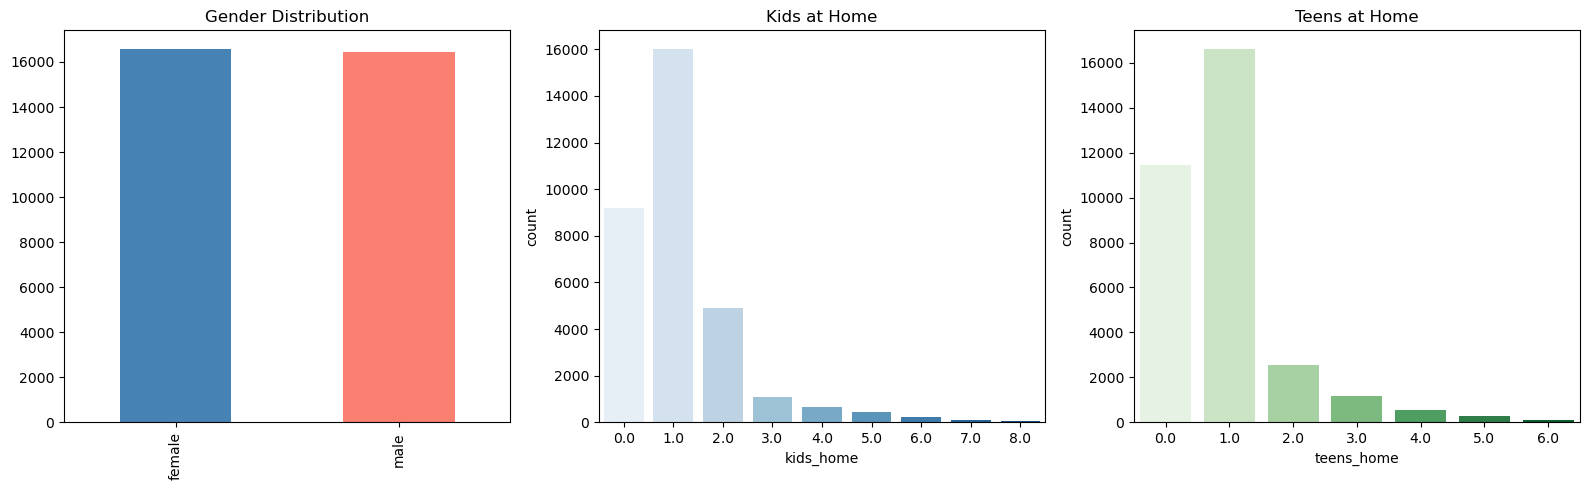

In [12]:
# Gender distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

customer_info['customer_gender'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('')

# Kids at home
sns.countplot(x='kids_home', data=customer_info, ax=axes[1], palette='Blues')
axes[1].set_title('Kids at Home')

# Teens at home
sns.countplot(x='teens_home', data=customer_info, ax=axes[2], palette='Greens')
axes[2].set_title('Teens at Home')

plt.tight_layout()
plt.show()

The customer base is evenly split between female and male customers (~16,500 each), suggesting gender is unlikely to be a dominant segmentation driver on its own, but may interact with spend behaviour.

Most customers have 0–1 kids at home, with very few having more than 3. The distribution is right-skewed, indicating families with many children are rare. The teens at home distribution follows a similar pattern.The majority of customers have 0 or 1 teen at home. Households with 4+ teens are negligible.

### 2.2) Age Distribution

/var/folders/qc/5kk_b6yn3yl9qxybq2_d4c4h0000gn/T/ipykernel_2990/2426458599.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_age = (pd.Timestamp.now() - pd.to_datetime(customer_info['customer_birthdate'], errors='coerce')).dt.days // 365


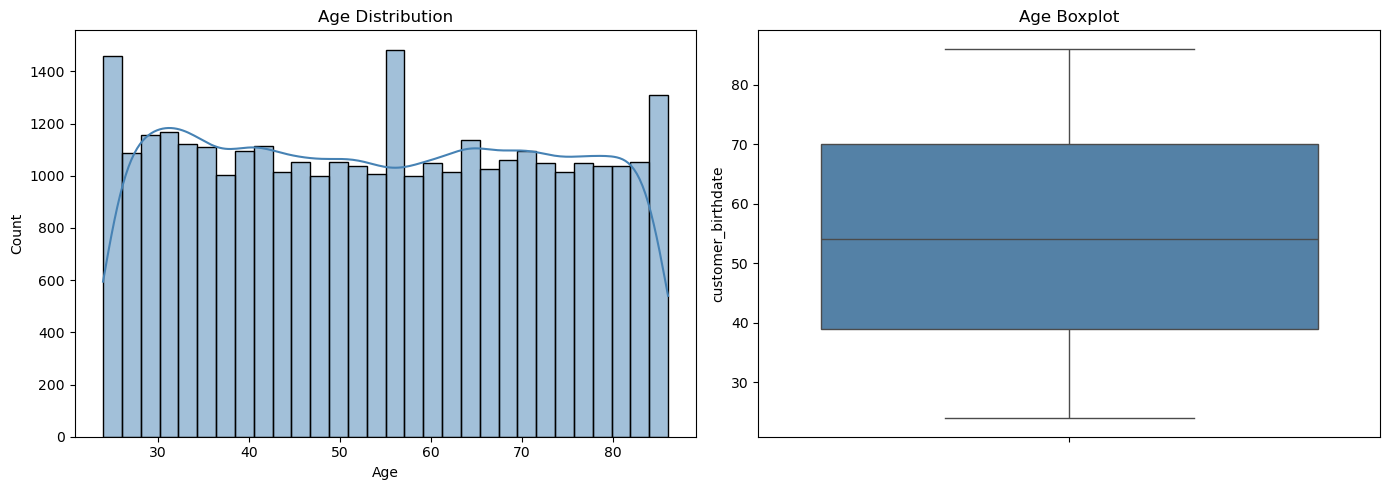

In [13]:
# Age distribution (raw birthdate → temporary age just for EDA)
temp_age = (pd.Timestamp.now() - pd.to_datetime(customer_info['customer_birthdate'], errors='coerce')).dt.days // 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(temp_age.dropna(), bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

sns.boxplot(y=temp_age.dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('Age Boxplot')

plt.tight_layout()
plt.show()

Customer ages range from approximately 25 to 85 years, with a remarkably flat, uniform distribution. This it suggests customers are spread evenly across age groups rather than concentrated in a particular life stage. There is a slight spike around age 28–30 and another around age 55–60.

The boxplot confirms ages between roughly 40 and 70 represent the interquartile range (Q1–Q3), with a median around 52. No extreme outliers are visible, the range is clean and no imputation of age values will distort the distribution significantly.

### 2.3) Education Level

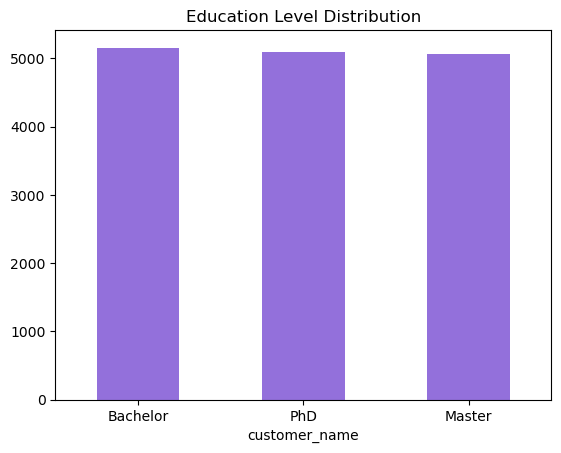

In [14]:
education = customer_info['customer_name'].str.extract(r'(?i)(Bsc|Msc|Phd)', expand=False)
education = education.str.title().map({'Bsc': 'Bachelor', 'Msc': 'Master', 'Phd': 'PhD'})

education.value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Education Level Distribution')
plt.xticks(rotation=0)
plt.show()

The education extraction revealed a data issue: the regex only matched 6 customers labelled "Master". This means the customer_name column does not reliably contain degree information for all customers, or the degree format varies. This column needs closer inspection before using education as a feature

 ## 3. Spend Behaviour Analysis

### 3.1) Spend Distributions per Category

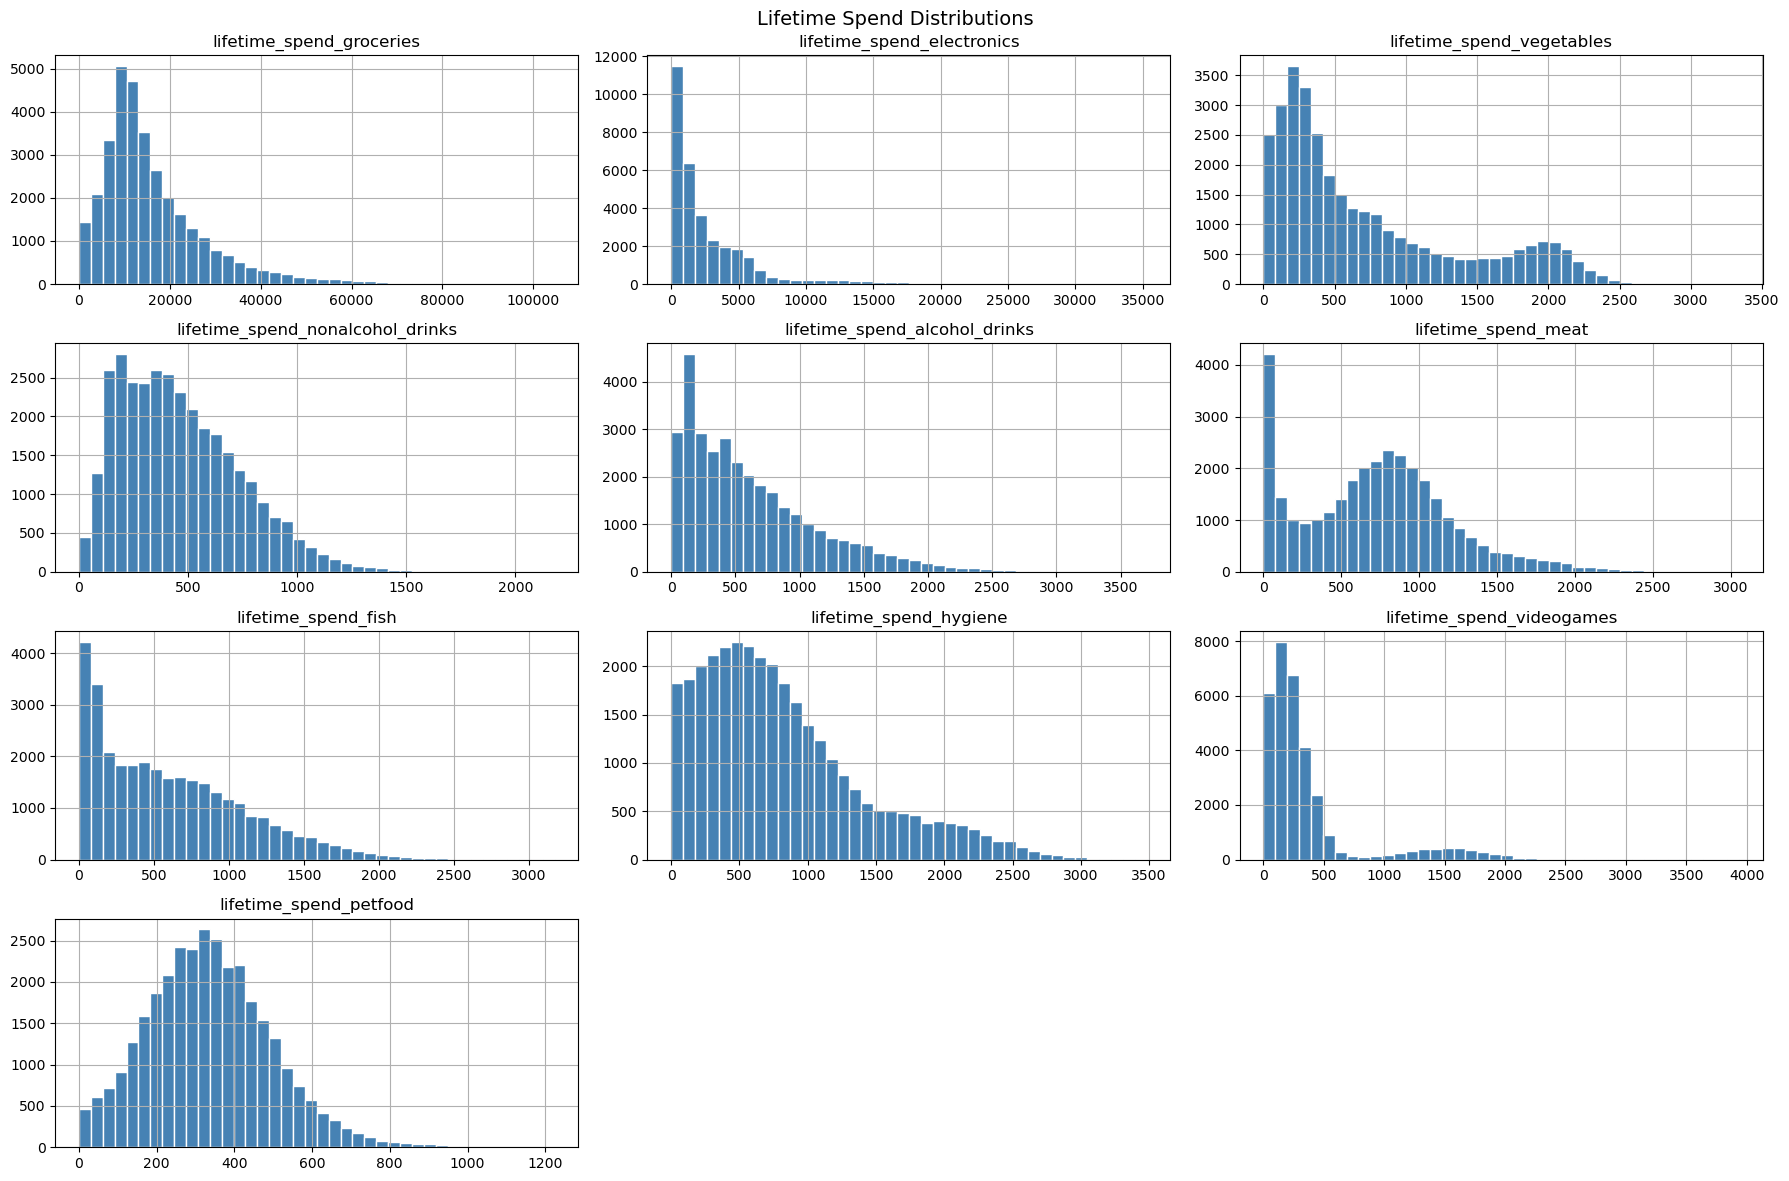

In [15]:
# 2. All spend distributions
spend_cols = [col for col in customer_info.columns if col.startswith('lifetime_spend')]
customer_info[spend_cols].hist(figsize=(18, 12), bins=40, color='steelblue', edgecolor='white')
plt.suptitle('Lifetime Spend Distributions', fontsize=14)
plt.tight_layout()
plt.show()

All spend categories show right-skewed distributions, which is typical for spending data. The majority of customers spend moderate amounts while a small number of high-value customers spend significantly more.


Groceries: widest range (up to ~100,000), most customers spend between 5,000–20,000. The dominant category.

Electronics: heavily concentrated near zero, with a long right tail and most customers spend little on electronics, but a distinct group spends a lot.

Vegetables: tightly concentrated at low values, with a secondary bump around 2,000–2,500 suggesting two sub-groups.

Non-alcoholic drinks: moderate right skew, fairly spread.

Alcohol drinks: sharp peak near zero, heavy right tail a clear split between non-drinkers and drinkers.

Meat: bimodal distribution. one group spends very little, another spends moderately (~500–1,000).

Fish: right-skewed with a large mass near zero — many customers don't buy fish at all.

Hygiene: relatively bell-shaped compared to others, more evenly spread.

Videogames: extreme right skew and the vast majority spend nothing or very little, small group spends heavily.

Petfood: near-normal distribution centred around 300–400  the most evenly distributed category.

### 3.2) Outlier Detection ( Boxplots)

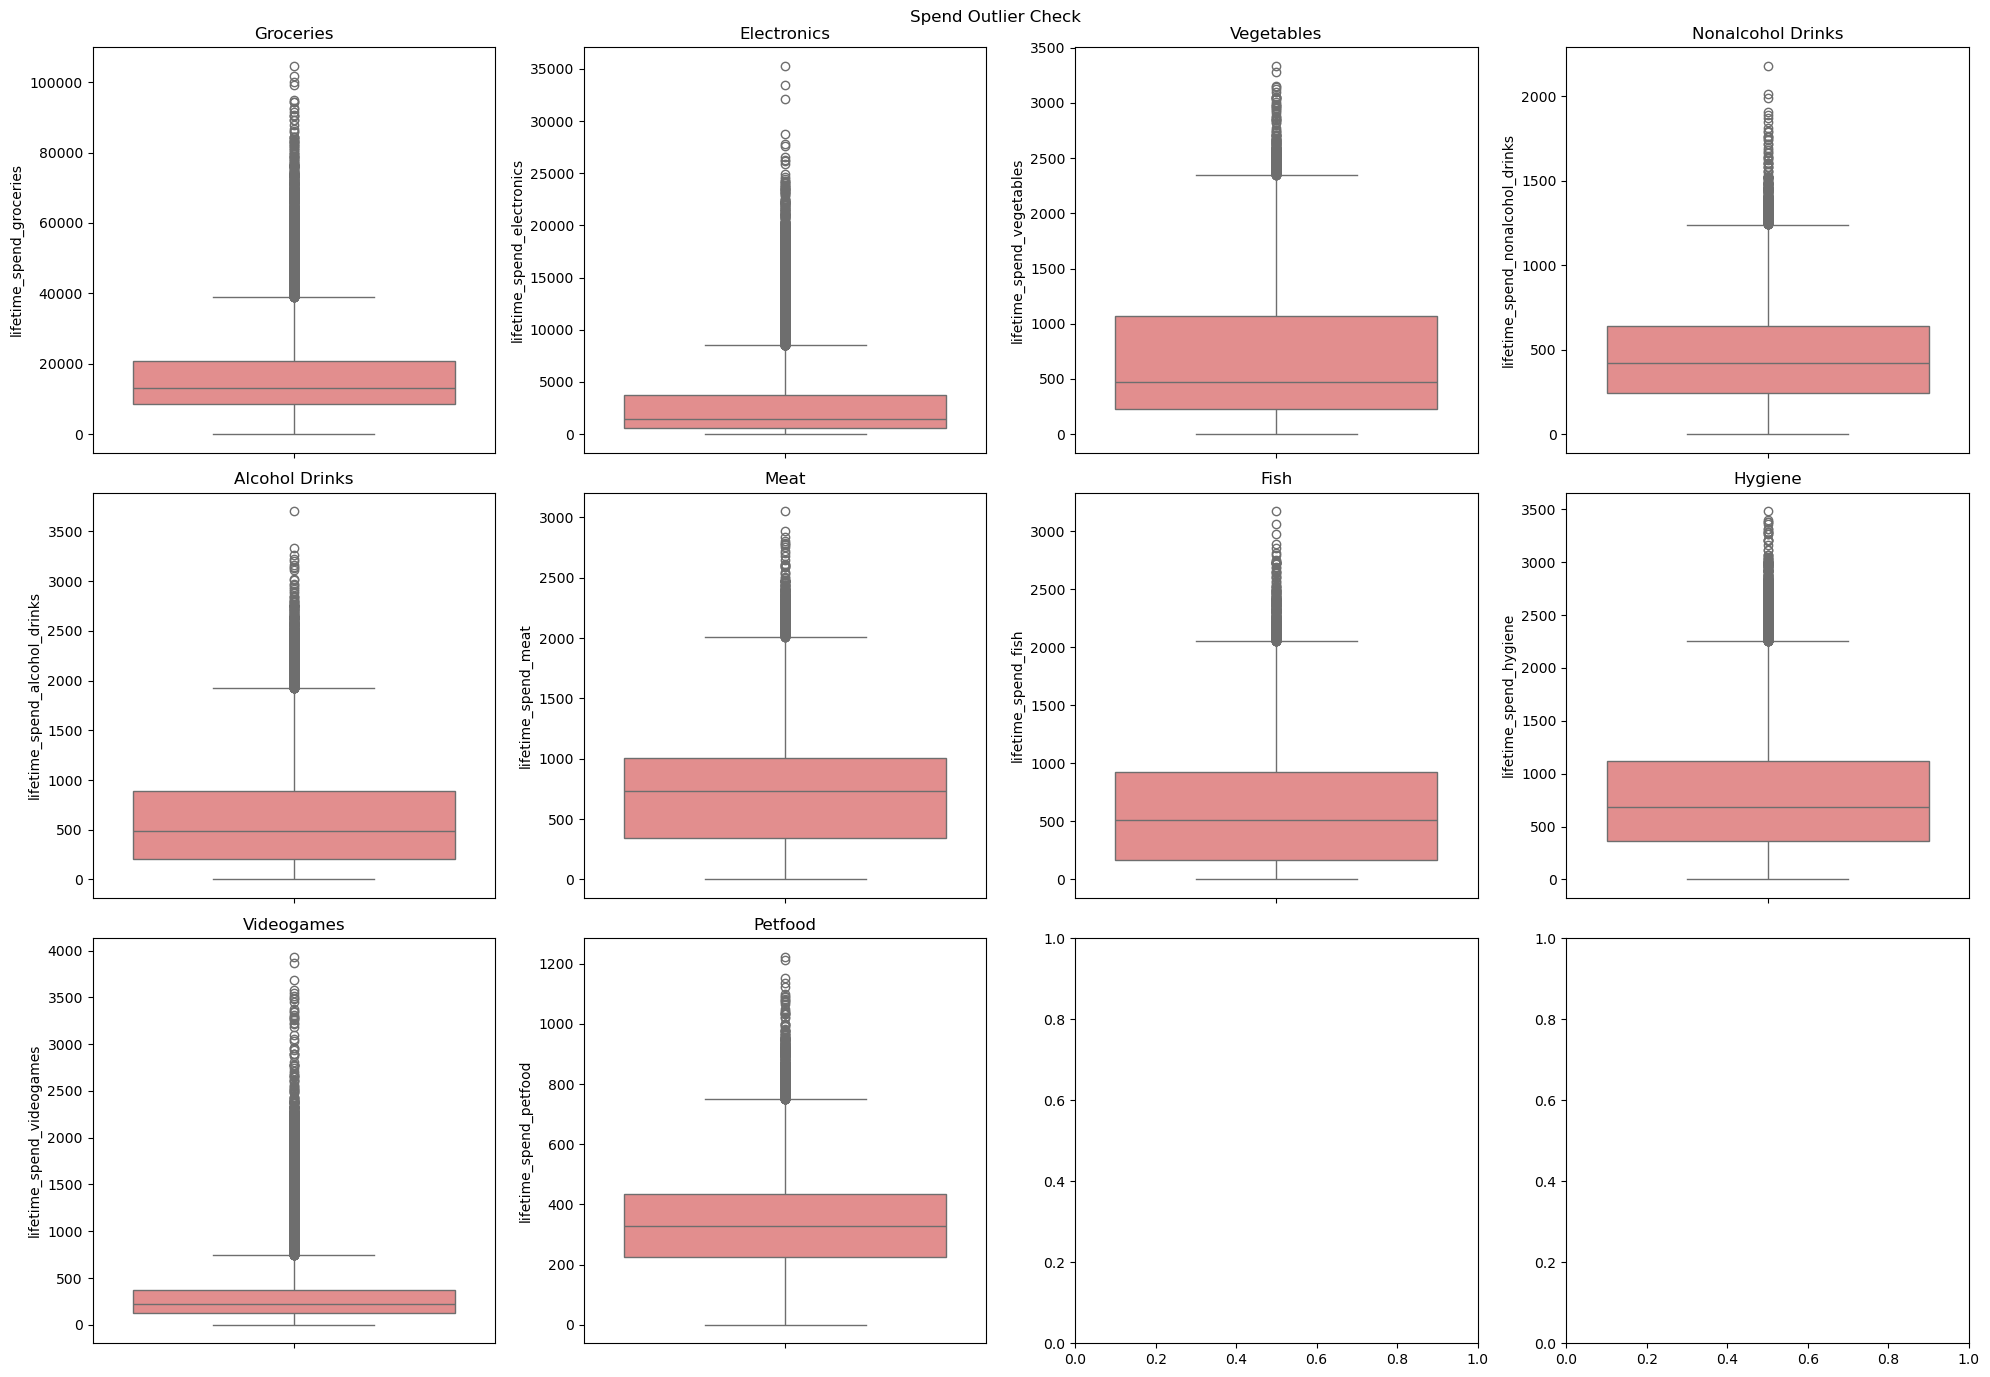

In [16]:
# 3. Spend outlier boxplots
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax, col in zip(axes.flatten(), spend_cols):
    sns.boxplot(y=customer_info[col], ax=ax, color='lightcoral')
    ax.set_title(col.replace('lifetime_spend_', '').replace('_', ' ').title())
plt.suptitle('Spend Outlier Check')
plt.tight_layout()
plt.show()

Outliers are present across all spend categories, particularly in:

Groceries: max ~100,000 vs. median ~13,000 — extreme high spenders exist.

Electronics: max ~35,000 vs. median ~2,500 — a small group of very high electronics buyers.

Videogames: many dots above the whisker — numerous high-spend outliers.

Fish, Meat, Alcohol: moderate outliers visible.

### 4. Correlation Analysis

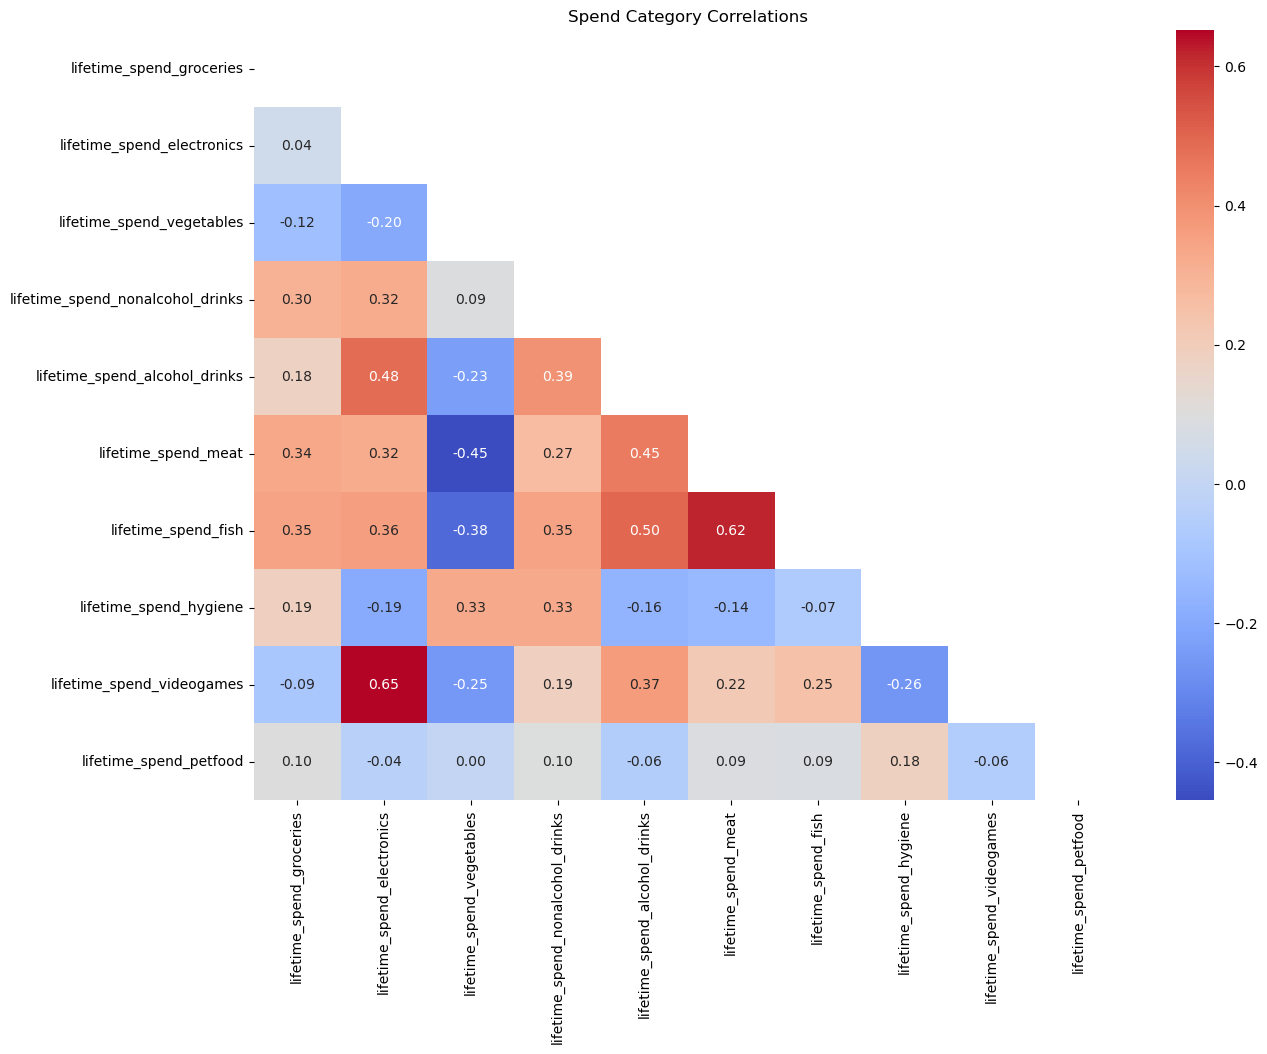

In [17]:
# 4. Correlation heatmap
import numpy as np
plt.figure(figsize=(14, 10))
corr = customer_info[spend_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.title('Spend Category Correlations')
plt.show()

The heatmap reveals that Electronics and Videogames have the strongest
positive correlation (0.65), followed by Fish and Meat (0.62) and it is suggesting
distinct tech-oriented and meat/fish buyer groups. Alcohol correlates
moderately with both Meat (0.45) and Fish (0.50), pointing to a
lifestyle-driven segment. On the negative side, Vegetables and Meat
show a moderate negative correlation (-0.45), indicating a likely
vegetarian or health-conscious segment. These correlations suggest
that PCA may be useful before clustering to reduce redundant features.


### 5) Behavioural Analysis

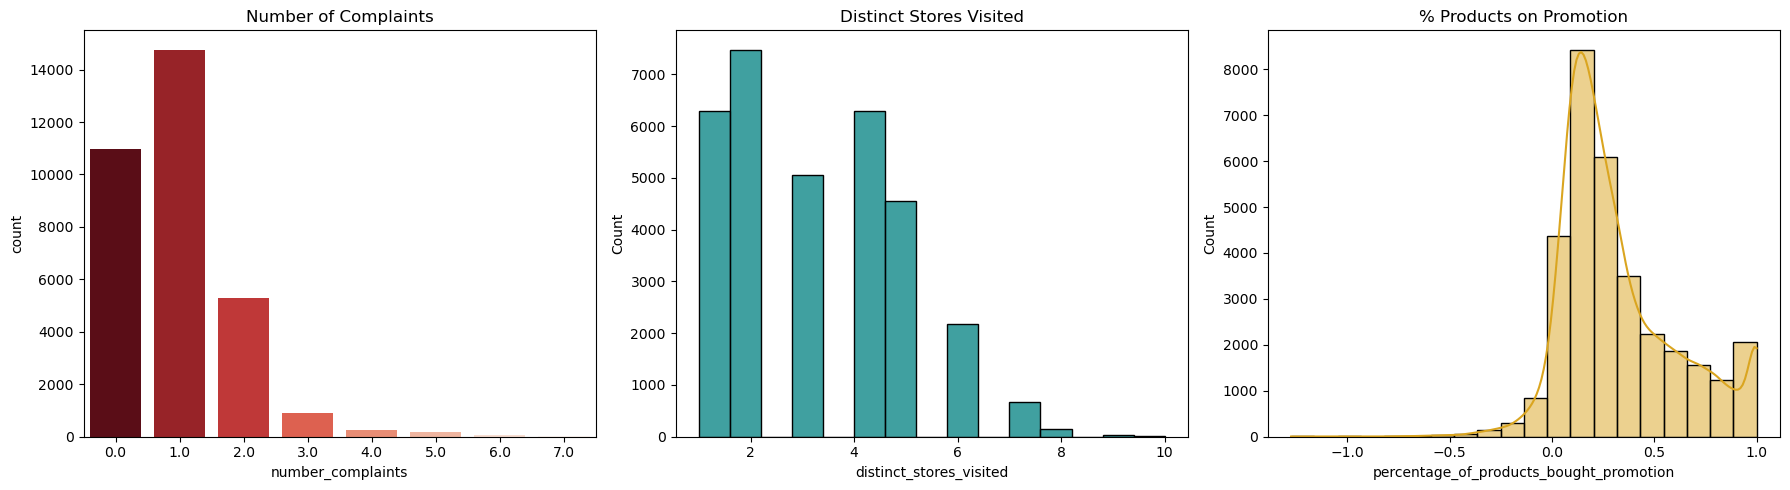

In [18]:
# 5. Complaints, stores visited, promo usage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='number_complaints', data=customer_info, ax=axes[0], palette='Reds_r', hue='number_complaints', legend=False)
axes[0].set_title('Number of Complaints')
sns.histplot(customer_info['distinct_stores_visited'].dropna(), bins=15, ax=axes[1], color='teal')
axes[1].set_title('Distinct Stores Visited')
sns.histplot(customer_info['percentage_of_products_bought_promotion'].dropna(), bins=20, ax=axes[2], color='goldenrod', kde=True)
axes[2].set_title('% Products on Promotion')
plt.tight_layout()
plt.show()

Complaints: The vast majority of customers have 0 or 1 complaints, with very few having more than 2. This is a low-variance feature and it may not differentiate clusters well, but a "high-complaint" segment could be meaningful for retention strategies.

Distinct stores visited: Most customers visit 2–6 distinct stores, with the peak around 2–4. Very few visit more than 8. This reflects moderate loyalty customers don't stick exclusively to one store but also don't spread widely.

Promotion usage: `The percentage_of_products_bought_promotion´ distribution is heavily concentrated near 0.0, with a sharp peak and long right tail extending to ~1.0. This means most customers buy few products on promotion, but a distinct group of heavy promotion users exists (right side of the distribution). This is a strong potential clustering dimension — price-sensitive vs. full-price shoppers.

### 5.2) Typical Shopping Hour

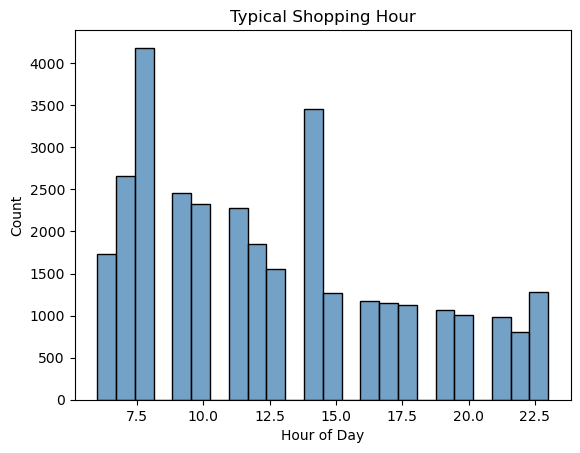

In [19]:
# 6. Typical shopping hour
sns.histplot(customer_info['typical_hour'].dropna(), bins=24, color='steelblue')
plt.title('Typical Shopping Hour')
plt.xlabel('Hour of Day')
plt.show()

There are two clear peaks in shopping behaviour:

A morning peak around 7:00–8:00 is the dominant shopping time

A mid-afternoon peak around 14:00–15:00

Shopping activity drops significantly in the evening (after 17:00) and is lowest late at night. This is meaningful for time-based promotions. morning and early afternoon campaigns will reach the largest audience.

### 5.3) Customer Tenure

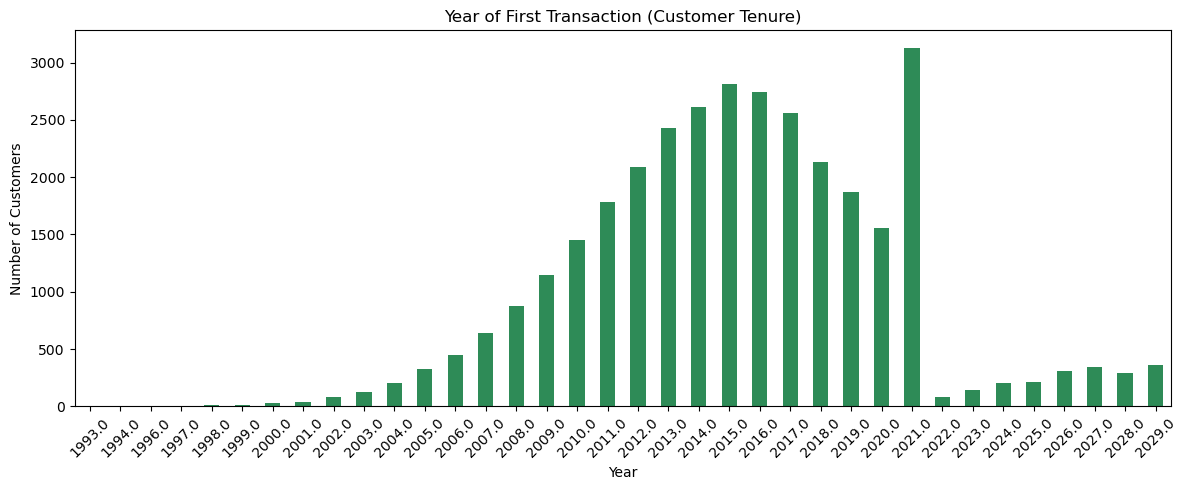

In [20]:
# Customer Tenure - Year of First Transaction
plt.figure(figsize=(12, 5))
customer_info['year_first_transaction'].value_counts().sort_index().plot(kind='bar', color='seagreen')
plt.title('Year of First Transaction (Customer Tenure)')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer acquisition grew steadily from the mid-1990s, with significant
growth from 2008 onwards and a peak in 2021 (~3,100 new customers).
The 2014–2016 period also saw consistently high acquisition (~2,600–2,800
customers per year). There is a sharp drop in 2022, followed by smaller
numbers in 2023–2029, which likely reflects more recently acquired customers
who have had less time to accumulate transaction history. The majority of
customers therefore have between 5–15 years of transaction history,
making tenure a potentially useful feature for segmentation.

## 6. Bivariate Analysis

### 6.1) Spend, Complaints & Stores Visited by Gender

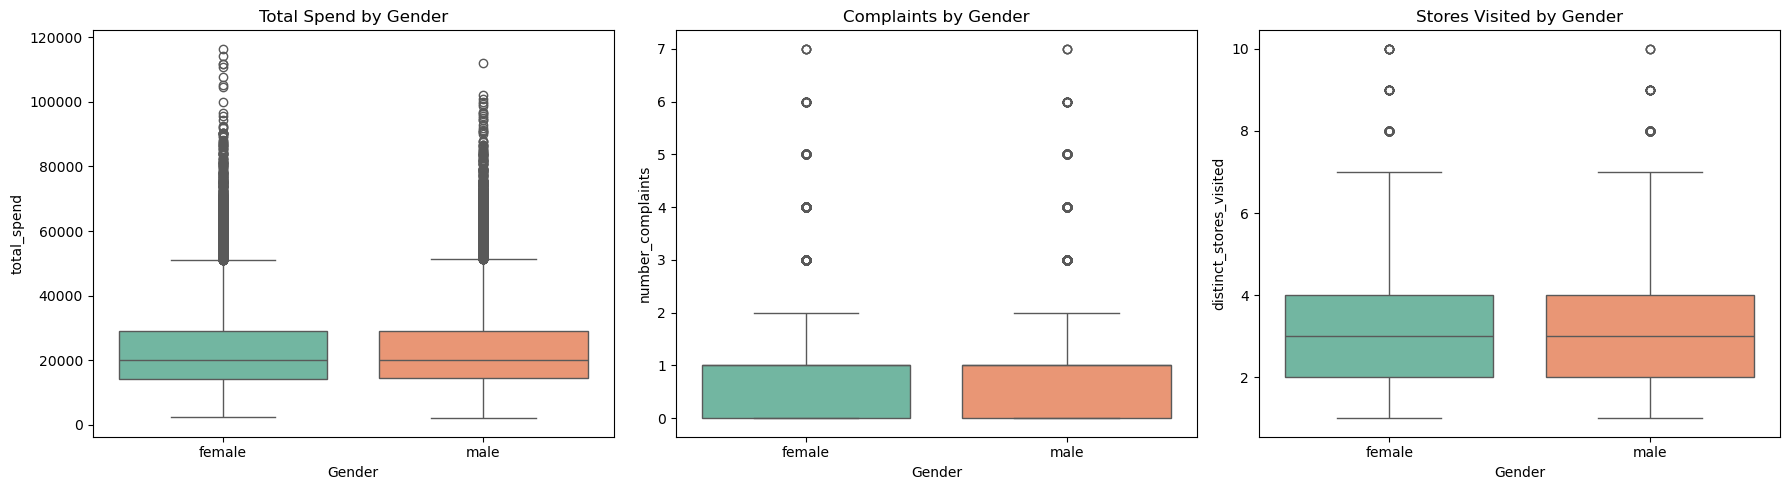

In [21]:
# Total spend by gender and complaints by gender
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

spend_cols = [col for col in customer_info.columns if col.startswith('lifetime_spend')]
customer_info['total_spend'] = customer_info[spend_cols].sum(axis=1)

sns.boxplot(x='customer_gender', y='total_spend', data=customer_info, ax=axes[0], hue='customer_gender', palette='Set2', legend=False)
axes[0].set_title('Total Spend by Gender')
axes[0].set_xlabel('Gender')

sns.boxplot(x='customer_gender', y='number_complaints', data=customer_info, ax=axes[1], hue='customer_gender', palette='Set2', legend=False)
axes[1].set_title('Complaints by Gender')
axes[1].set_xlabel('Gender')

sns.boxplot(x='customer_gender', y='distinct_stores_visited', data=customer_info, ax=axes[2], hue='customer_gender', palette='Set2', legend=False)
axes[2].set_title('Stores Visited by Gender')
axes[2].set_xlabel('Gender')

plt.tight_layout()
plt.show()

Both female and male customers show nearly identical total spend distributions,
with a median around 20,000 and a wide spread of outliers reaching up to 120,000.
This suggests gender alone is not a strong differentiator for spending behaviour.
Complaint levels are also very similar across genders, with most customers having
0–1 complaints regardless of gender. Stores visited follows the same pattern where
both groups visit roughly 2–4 distinct stores on average, with no meaningful
difference between male and female customers.

### 6.2) Total Spend vs Age

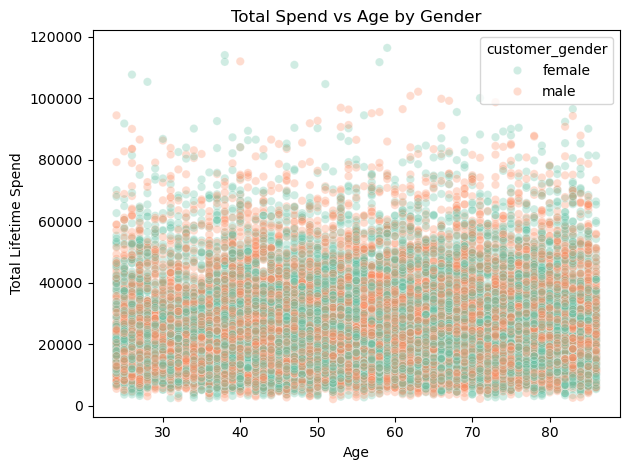

In [22]:
# Total spend vs age coloured by gender
temp_age = (pd.Timestamp.now() - pd.to_datetime(customer_info['customer_birthdate'], errors='coerce', format='mixed')).dt.days // 365
plot_df = customer_info.copy()
plot_df['age'] = temp_age

sns.scatterplot(x='age', y='total_spend', hue='customer_gender', data=plot_df, alpha=0.3, palette='Set2')
plt.title('Total Spend vs Age by Gender')
plt.xlabel('Age')
plt.ylabel('Total Lifetime Spend')
plt.tight_layout()
plt.show()

The scatter plot shows no clear linear relationship between age and total
lifetime spend. The high and low spenders exist across all age groups from 25
to 85. Female and male customers are evenly mixed throughout the plot with
no visible spending gap between genders at any age. This confirms that age
and gender alone are insufficient to define customer segments, and that
spend category patterns will be more informative for clustering.


 ## 7. Basket Analysis

### 7.1) Top 20 Most Purchased Products

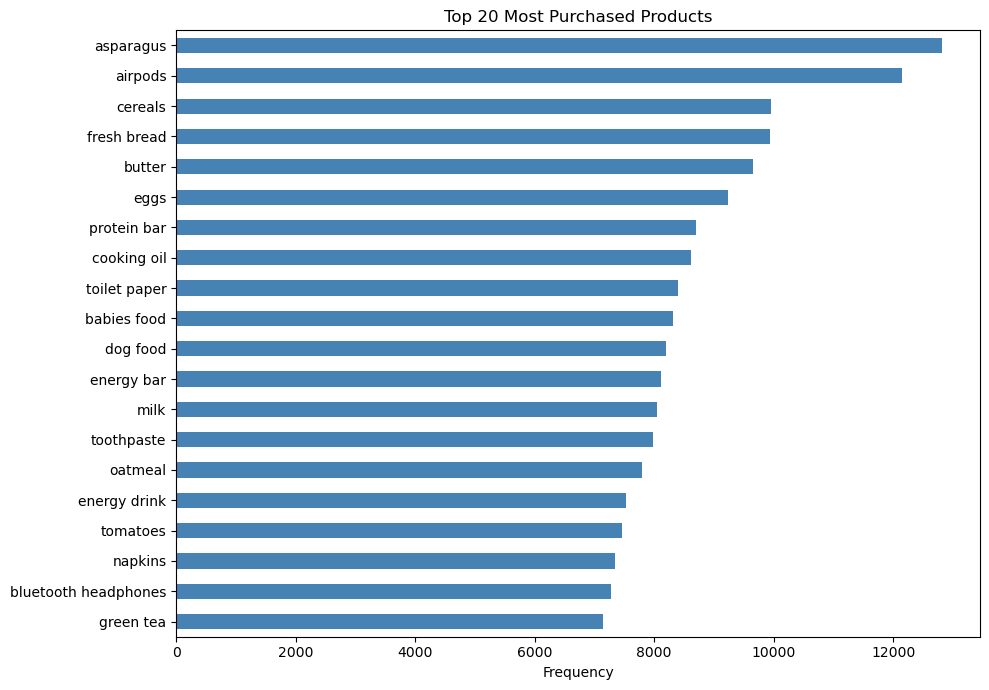

In [23]:
# 7. Top 20 products from baskets
from ast import literal_eval
from collections import Counter
customer_basket['list_of_goods'] = customer_basket['list_of_goods'].apply(literal_eval)
all_items = [item for sublist in customer_basket['list_of_goods'] for item in sublist]
top_20 = pd.Series(Counter(all_items)).nlargest(20)
top_20.sort_values().plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.title('Top 20 Most Purchased Products')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

The presence of Airpods and Bluetooth headphones in the top 20 confirms that electronics are frequently purchased alongside groceries. The babies food and dog food entries suggest distinct family and pet-owner segments and is useful for targeted promotions. These findings align well with the spend category correlations observed in Section 4.



# PRE PROCESSING


#### 1.1) dropping Irrelevant Columns


In [24]:
customer_info_processed = customer_info.copy()

cols_to_drop = ['customer_name', 'latitude', 'longitude']
customer_info_processed.drop(columns=cols_to_drop, inplace=True)

### 1.2) Extract Age from Birthdate

In [25]:
customer_info_processed['age'] = (
    pd.Timestamp.now() - pd.to_datetime(
        customer_info_processed['customer_birthdate'],
        format='mixed',
        dayfirst=False,
        errors='coerce'
    )
).dt.days // 365

customer_info_processed.drop(columns=['customer_birthdate'], inplace=True)

`customer_birthdate` is stored as a string object. We parse it and compute the customer's age in years. The original column is then dropped.

### 1.3 Encode Categorical Features

In [26]:
customer_info_processed['customer_gender'] = customer_info_processed['customer_gender'].map({'female': 0, 'male': 1})

customer_info_processed['has_loyalty_card'] = customer_info_processed['loyalty_card_number'].notna().astype(int)
customer_info_processed.drop(columns=['loyalty_card_number'], inplace=True)

`customer_gender` is binary (male/female) and is encoded as 0/1. `loyalty_card_number` is always 1.0 when present, so it is converted into a binary flag indicating whether the customer has a loyalty card.

### 1.4 Handle Missing Values

In [27]:
cols_with_missing = customer_info_processed.columns[customer_info_processed.isnull().any()].tolist()
print("Columns with missing values:", cols_with_missing)

for col in cols_with_missing:
    customer_info_processed[col] = customer_info_processed[col].fillna(customer_info_processed[col].median())

print("Missing values after imputation:", customer_info_processed.isnull().sum().sum())

Columns with missing values: ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'percentage_of_products_bought_promotion', 'age']
Missing values after imputation: 0




Missing values are imputed with the **median** of each column. The median is preferred over the mean because the spend distributions are right-skewed with outliers, making the median a more robust central estimate.

### 1.5 Clip Outliers (IQR Method)

In [28]:
spend_cols = [col for col in customer_info_processed.columns if col.startswith('lifetime_spend')]

for col in spend_cols:
    Q1 = customer_info_processed[col].quantile(0.25)
    Q3 = customer_info_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    customer_info_processed[col] = customer_info_processed[col].clip(lower=lower, upper=upper)

Spend columns show heavy right-skewed distributions with extreme outliers (e.g. groceries max ~100,000 vs median ~13,000). Rather than removing rows, we clip outlier values to the 1.5×IQR boundary. This preserves all customers while reducing the distortion caused by extreme spenders.

### 1.6 Feature Scaling

In [29]:
cols_to_exclude = ['customer_id']
feature_cols = [col for col in customer_info_processed.columns if col not in cols_to_exclude]

scaler = RobustScaler()
customer_info_scaled = customer_info_processed.copy()
customer_info_scaled[feature_cols] = scaler.fit_transform(customer_info_processed[feature_cols])

print("Preprocessing complete. Shape:", customer_info_scaled.shape)
customer_info_scaled.head()

Preprocessing complete. Shape: (33038, 23)


,customer_id,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,total_spend,age,has_loyalty_card
0,3,0.0,0.0,0.0,0.0,0.0,-0.104564,1.000324,0.000,-0.118824,...,-0.409904,-0.178905,0.135246,0.278049,0.461538,1.147251,0.714286,-0.108111,0.064516,0.0
1,4,0.0,0.0,-1.0,-1.0,-0.5,0.056867,-0.164504,0.000,1.868445,...,-0.682256,1.594126,0.450820,1.648780,0.048951,-0.262009,-0.285714,0.003639,-0.129032,0.0
2,5,1.0,-1.0,-1.0,0.0,-0.5,-0.048972,-0.476963,-0.125,0.101849,...,-0.327373,-0.238985,-0.500000,-0.512195,-0.293706,-0.498290,-1.428571,-0.314946,0.000000,-1.0
3,7,1.0,-1.0,-1.0,1.0,-1.0,-0.453084,-0.118430,0.750,-0.469233,...,0.786795,-0.268358,2.102459,-0.697561,-0.216783,0.041426,0.857143,-0.355552,-0.354839,0.0
4,8,1.0,-1.0,-1.0,2.0,-1.0,-0.313775,2.215120,0.625,-0.110336,...,0.693260,-0.519359,2.102459,0.556098,-0.818182,-0.154704,0.857143,0.382078,0.064516,0.0


All spend features and numerical columns are scaled using `RobustScaler`, which is robust to outliers as it scales based on the median and IQR rather than mean and standard deviation. This is especially appropriate given the right-skewed spend distributions identified in the EDA.

In [30]:

# 1. Save the processed dataframes to CSV files
customer_info_processed.to_csv('customer_info_processed.csv', index=False)
customer_info_scaled.to_csv('customer_info_scaled.csv', index=False)

# 2. Save the feature columns list
import json
with open('feature_cols.json', 'w') as f:
    json.dump(list(feature_cols), f)

print("💾 Cleaned data saved successfully for the segmentation phase!")

💾 Cleaned data saved successfully for the segmentation phase!
